# Wardrobe AI

An AI assistant that predicts the optimal outfit type based on weather conditions (temperature, wind speed, rain) and planned activity (walking, office, sports).

**Method**: k-Nearest Neighbors (k-NN)

The idea is find past days with similar conditions and see what clothing worked.


## Data

Hand-collected observations: for each day, we log the weather conditions, the activity, and the outfit felt right.

| Feature     | Type                  | Description                                 |
| ----------- | --------------------- | ------------------------------------------- |
| Temperature | ºC                    | Air temperature                             |
| Wind speed  | m/s                   | Wind speed                                  |
| Is raining  | binary (0/1)          | Whether it's raining                        |
| Activity    | categorical (encoded) | office(0), walking(1), sports(2), casual(3) |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# This example data for demonstration is generated by AI
data = {
    "temp": [30, 25, 15, 15, 5, -2, 20, 10, 28, 8, 22, 0, 12, 18, 35, -5, 10, 17, 6, 23],
    "wind": [ 2,  5,  3, 12, 8,  3,  2, 15,  3, 4,  7, 5, 10,  2,  1, 10,  6,  8, 3,  4],
    "is_raining": [ 0,  0,  0,  1, 0,  1,  0,  1,  0, 1,  0, 0,  1,  0,  0,  0,  1,  0, 0,  0],
    "activity": [ 1,  2,  0,  1, 1,  3,  2,  1,  3, 0,  1, 1,  1,  2,  3,  1,  0,  1, 2,  2],
    "outfit": [
        "t-shirt",     
        "sportswear",  
        "light jacket",
        "rain jacket", 
        "heavy coat",  
        "heavy coat",  
        "sportswear",  
        "rain jacket", 
        "t-shirt",     
        "sweater",     
        "light jacket",
        "heavy coat",  
        "rain jacket", 
        "sportswear",  
        "t-shirt",     
        "heavy coat",  
        "sweater",     
        "light jacket",
        "sweater",     
        "sportswear",  
    ],
}

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} observations, {df["outfit"].nunique()} outfit categories")
df


Dataset: 20 observations, 6 outfit categories


,temp,wind,is_raining,activity,outfit
0,30,2,0,1,t-shirt
1,25,5,0,2,sportswear
2,15,3,0,0,light jacket
3,15,12,1,1,rain jacket
4,5,8,0,1,heavy coat
5,-2,3,1,3,heavy coat
6,20,2,0,2,sportswear
7,10,15,1,1,rain jacket
8,28,3,0,3,t-shirt
9,8,4,1,0,sweater


## Data visualization

The following image shows how temperature and wind speed relate to outfit choices.


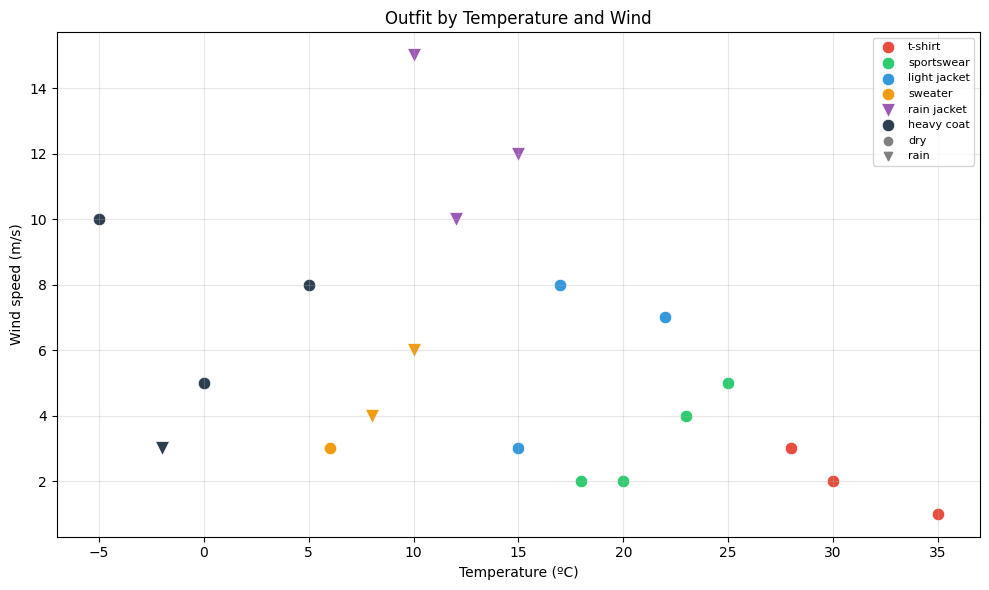

In [40]:
outfit_colors = {
    "t-shirt": "#e74c3c",
    "sportswear": "#2ecc71",
    "light jacket": "#3498db",
    "sweater": "#f39c12",
    "rain jacket": "#9b59b6",
    "heavy coat": "#2c3e50",
}

fig, ax = plt.subplots(figsize=(10, 6))

for outfit, color in outfit_colors.items():
    subset = df[df["outfit"] == outfit]
    dry = subset[subset["is_raining"] == 0]
    rain = subset[subset["is_raining"] == 1]

    if not dry.empty:
        ax.scatter(dry["temp"], dry["wind"], c=color, marker="o", label=outfit, s=80, edgecolors="white", linewidth=0.5)
    
    if not rain.empty:
        ax.scatter(rain["temp"], rain["wind"], c=color, marker="v", label=f"{outfit}" if dry.empty else None, s=100, edgecolors="white", linewidth=0.5)

ax.scatter([], [], c="gray", marker="o", label="dry")
ax.scatter([], [], c="gray", marker="v", label="rain")

ax.set_xlabel("Temperature (ºC)")
ax.set_ylabel("Wind speed (m/s)")
ax.set_title("Outfit by Temperature and Wind")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Training the k-NN model

The features are scaled so that the temperature and wind speed contribute equally to the distance calculation. Without scaling, temperature would dominate because its values are larger.


In [41]:
feature_cols = ["temp", "wind", "is_raining", "activity"]

X = df[feature_cols].values
y = df["outfit"].values

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_scaled, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Making Predictions


In [42]:
activity_names = {0: "office", 1: "walking", 2: "sports", 3: "casual"}

# Example test scenarios are AI generated
test_scenarios = [
    {"temp": 14, "wind": 10, "is_raining": 0, "activity": 1, "desc": "14°C, windy, dry, walking"},
    {"temp": 14, "wind":  2, "is_raining": 0, "activity": 0, "desc": "14°C, calm, dry, office"},
    {"temp": 27, "wind":  3, "is_raining": 0, "activity": 2, "desc": "27°C, light breeze, dry, sports"},
    {"temp":  3, "wind": 12, "is_raining": 1, "activity": 1, "desc": "3°C, windy, rain, walking"},
    {"temp": 20, "wind":  5, "is_raining": 1, "activity": 3, "desc": "20°C, breezy, rain, casual"},
]

print(f"{'Scenario':<40} {'Prediction':>15}")
print("-" * 57)

for s in test_scenarios:
    X_new = scaler.transform([[s["temp"], s["wind"], s["is_raining"], s["activity"]]])
    prediction = model.predict(X_new)[0]
    print(f"{s["desc"]:<40} {prediction:>15}")


Scenario                                      Prediction
---------------------------------------------------------
14°C, windy, dry, walking                   light jacket
14°C, calm, dry, office                     light jacket
27°C, light breeze, dry, sports               sportswear
3°C, windy, rain, walking                    rain jacket
20°C, breezy, rain, casual                    heavy coat


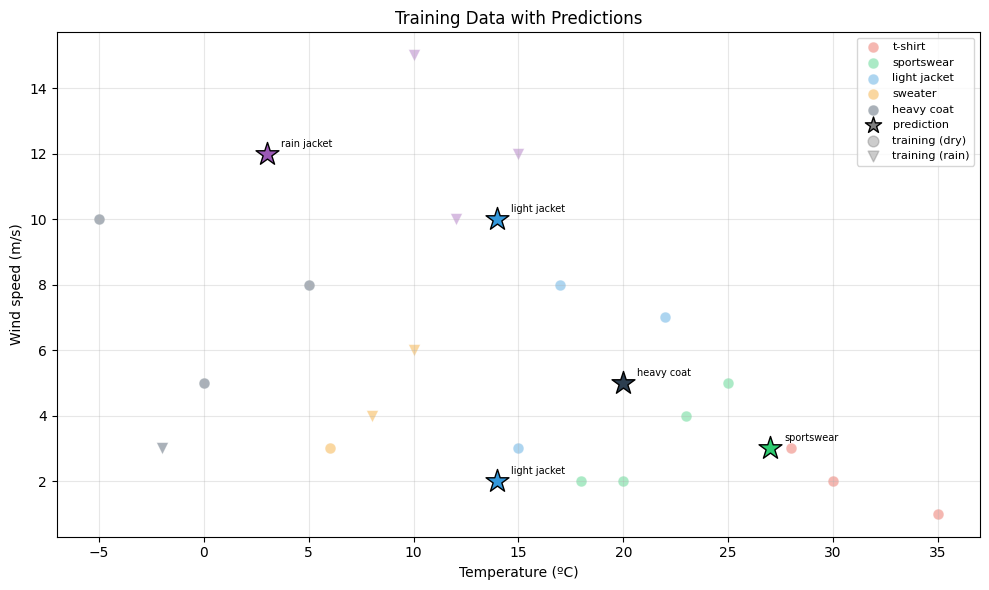

In [43]:

fig, ax = plt.subplots(figsize=(10, 6))

# Training data
for outfit, color in outfit_colors.items():
    subset = df[df["outfit"] == outfit]
    dry = subset[subset["is_raining"] == 0]
    rain = subset[subset["is_raining"] == 1]

    if not dry.empty:
        ax.scatter(dry["temp"], dry["wind"], c=color, marker="o", label=outfit, s=60, alpha=0.4, edgecolors="white", linewidth=0.5)
    if not rain.empty:
        ax.scatter(rain["temp"], rain["wind"], c=color, marker="v", label=None, s=70, alpha=0.4, edgecolors="white", linewidth=0.5)

# Prediction points
for s in test_scenarios:
    X_new = scaler.transform([[s["temp"], s["wind"], s["is_raining"], s["activity"]]])
    pred = model.predict(X_new)[0]
    color = outfit_colors[pred]
    marker = "v" if s["is_raining"] else "o"
    ax.scatter(s["temp"], s["wind"], c=color, marker="*",s=300, edgecolors="black", linewidth=1, zorder=5)
    ax.annotate(pred, (s["temp"], s["wind"]), textcoords="offset points", xytext=(10, 5), fontsize=7)

ax.scatter([], [], c="gray", marker="*", s=150, edgecolors="black", label="prediction")
ax.scatter([], [], c="gray", marker="o", s=60, alpha=0.4, label="training (dry)")
ax.scatter([], [], c="gray", marker="v", s=60, alpha=0.4, label="training (rain)")

ax.set_xlabel("Temperature (ºC)")
ax.set_ylabel("Wind speed (m/s)")
ax.set_title("Training Data with Predictions")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In the plot, we can see that some prediction do not seem correct.  
The problem is the small dataset: with only 20 samples, the model can match against neighbors that aren't really similar in the most important features.
